## Molmo2 — Understand and Fine-tune

* Molmo2 is a multimodal LLM from AI2 (Allen Institute) with fully open-sourced code, weights, and training data
* We fine-tune it on our SLEAP mouse home cage VQA dataset using LoRA
* This notebook is designed to run in **Google Colab** with a GPU runtime

```
┌──────────────────────┬──────────────────────┬──────────────────────────────────────────┬────────────────────────────────┐      
│                      │        LLaVA         │                PaliGemma                 │             Molmo2             │
├──────────────────────┼──────────────────────┼──────────────────────────────────────────┼────────────────────────────────┤      
│ Vision encoder       │ CLIP ViT             │ SigLIP ViT                               │ CLIP ViT (DFN)                 │
│ LLM backbone         │ Vicuna/LLaMA         │ Gemma                                    │ OLMo2                          │      
│ Projection           │ Linear/MLP           │ Linear                                   │ MLP with multi-scale crops     │      
│ Training stages      │ 2 (align → instruct) │ 3 (unimodal → multimodal → task)         │ 2 (multimodal pretrain → SFT)  │
│ Special capabilities │ General VQA          │ Detection, segmentation (loc/seg tokens) │ Pointing, tracking, video      │
│ Openness             │ Weights + code       │ Weights + code                           │ Weights + code + training data │
│ Released by          │ UW Madison           │ Google                                   │ AI2 (Allen Institute)          │
└──────────────────────┴──────────────────────┴──────────────────────────────────────────┴────────────────────────────────┘   
```

I was actually impressed at how good Molmo2 was out of the box on these images. Their previous version had a very difficult time even telling what was in the image, but this one is much sharper. Still, as a learning experience (and this is probably something that would actually need to be done to use this model for real scientific research), let's fine tune to get exactly the answers we want to help ground pose, location, and better description of the images.

```
┌──────────────────────────┬────────────────────────────┬────────────────────────────────────────────────────────────────────┐   
│         Question         │       Generic answer       │                       Domain-precise answer                        │
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤   
│ "How many mice and       │ "Two mice, one top one     │ "2 mice. The mouse on the left at (640, 320), the mouse on the    │
│ where?"                  │ bottom"                    │ right at (400, 800)"                                               │
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤   
│ "What body parts are     │ "Part of the mouse is      │ "Left ear and tail tip of the mouse on the left are occluded"     │
│ occluded?"               │ hidden"                    │                                                                    │   
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤
│ "Estimate the            │ Can't do this              │ "Snout-to-snout distance is approximately 150px. They are at      │   
│ inter-mouse distance"    │                            │ moderate distance."                                                │   
└──────────────────────────┴────────────────────────────┴────────────────────────────────────────────────────────────────────┘
```

* lets inspect the VQA dataset we created. 

Train: 11011 QA pairs
Val:   1976 QA pairs
data/frames/frame_0854.png
data/frames/frame_0797.png
data/frames/frame_0839.png
data/frames/frame_0226.png
data/frames/frame_0744.png
data/frames/frame_0557.png


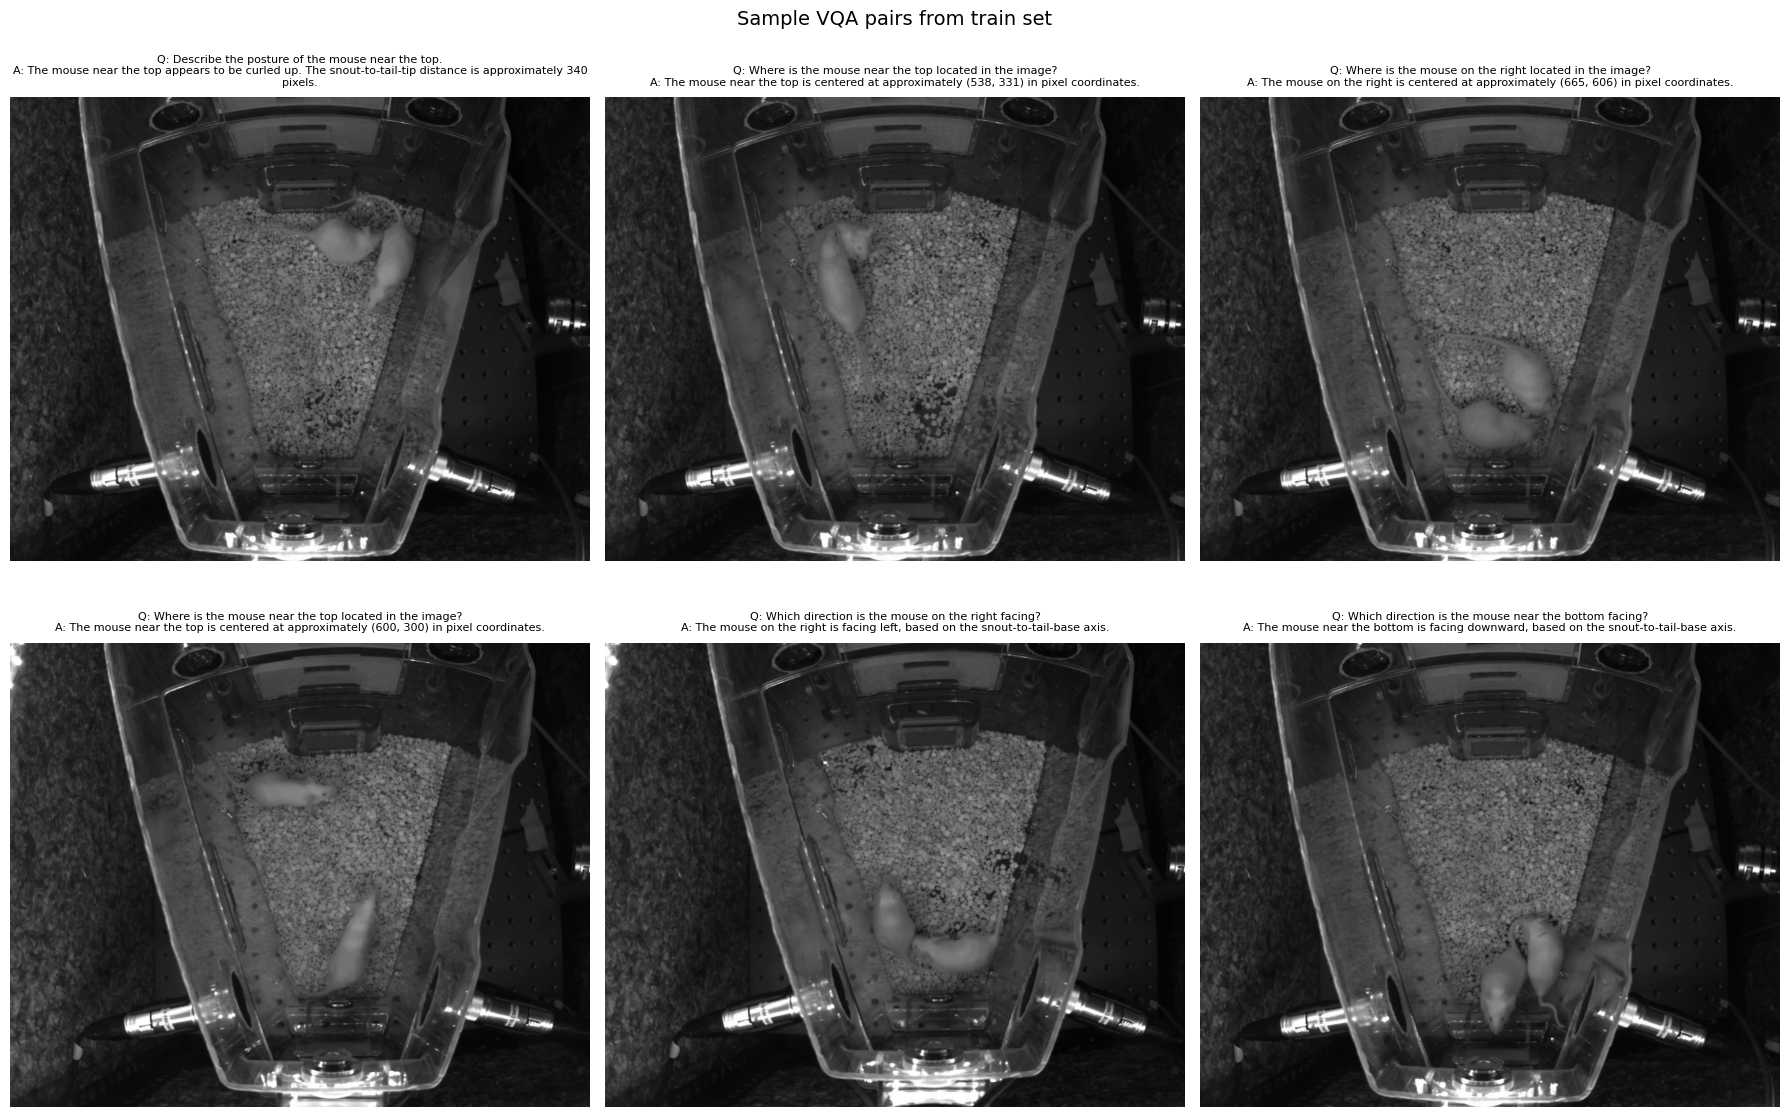

In [9]:
import json
import matplotlib.pyplot as plt
from PIL import Image
import random

# Load from saved JSON
with open("../data/vqa/train.json") as f:
    train_data = json.load(f)

with open("../data/vqa/val.json") as f:
    val_data = json.load(f)

print(f"Train: {len(train_data)} QA pairs")
print(f"Val:   {len(val_data)} QA pairs")

# Show random samples with their images
random.seed(1023)
samples = random.sample(train_data, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, sample in zip(axes.flat, samples):
    old_dir = sample["image"]
    new_dir = f"../{old_dir}"
    img = Image.open(new_dir)
    print(sample["image"])
    ax.imshow(img, cmap="gray")
    # Wrap the Q/A text for display
    q = sample["question"]
    a = sample["answer"]
    ax.set_title(f"Q: {q}\nA: {a}", fontsize=8, wrap=True, pad=10)
    ax.axis("off")

plt.suptitle("Sample VQA pairs from train set", fontsize=14)
plt.tight_layout()
plt.show()

## Now we upload the data

* use huggingface datasets to create a VQA dataset, and we will download it in google collab to do our fine-tune


```python
from huggingface_hub import snapshot_download                                                                                    
snapshot_download("jpoberhauser/sleap-mice-vqa", local_dir="data")
```

google collab is here: https://colab.research.google.com/drive/1QzknL7zBBUxBIJR2Dz2paU568PNIBuYO?usp=sharing

## Fine-tuning Molmo2-4B with LoRA (Colab)

The cells below are the Colab workflow. Run in order after a fresh runtime restart.

1. Install deps + fix CUDA libs
2. Authenticate + download dataset
3. Load model in **float32** (avoids CUBLAS dtype issues; we have 98GB VRAM)
4. Test inference on a sample image
5. Attach LoRA adapters
6. Format VQA data + create datasets
7. Define collator + train
8. Evaluate + save

### Colab Cell 1: Environment setup

Run this **first** before any imports.

In [ ]:
# Cell 1a: Install dependencies
%pip install --upgrade \
  torch \
  torchvision \
  "transformers>=4.57.1" \
  "datasets>=3.0.1" \
  "accelerate>=0.34.2" \
  "bitsandbytes>=0.44.0" \
  "trl>=0.15.0" \
  "peft>=0.13.0" \
  pillow tensorboard

# Fix CUDA library paths (Colab-specific)
!ln -sf /usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0 /usr/lib/libnvrtc-builtins.so.13.0

### Colab Cell 2: Authenticate and download dataset

In [ ]:
from huggingface_hub import login, snapshot_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)

snapshot_download("jpoberhauser/sleap-mice-vqa", repo_type="dataset", local_dir="data")

# Unzip frames if they were uploaded as a zip
import os
if os.path.exists("data/frames.zip") and not os.path.exists("data/frames/frame_0000.png"):
    !unzip -q data/frames.zip -d data/
    print("Frames unzipped.")
else:
    print("Frames already available.")

### Colab Cell 3: Load model in float32

We load in float32 to avoid CUBLAS dtype errors during training. With 98GB VRAM this is fine (~16GB for the 4B model).

In [ ]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

model_id = "allenai/Molmo2-4B"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
print(f"Model loaded. dtype: {model.dtype}")

### Colab Cell 4: Test inference before fine-tuning

In [ ]:
from PIL import Image

img = Image.open("data/frames/frame_0000.png").convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            dict(type="image", image=img),
            dict(type="text", text="How many mice are in this image? Describe their positions and postures."),
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].size(1):]
print("Base model response:")
print(processor.tokenizer.decode(generated_tokens, skip_special_tokens=True))

### Colab Cell 5: Attach LoRA adapters

LoRA freezes the base model and injects small trainable matrices. We target:
- `att_proj` — fused Q/K/V projection (where the model decides what to attend to)
- `attn_out` — output projection W_O (how attention results mix back in)
- `ff_proj` — feed-forward layer (helps learn domain vocabulary)

In [ ]:
from peft import LoraConfig, get_peft_model

# Freeze the vision encoder — we only want to fine-tune the language model
for param in model.model.vision_backbone.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    target_modules=["att_proj", "attn_out", "ff_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Forward hook to enable gradients through frozen layers.
# We need to find the correct path to the first transformer block.
def make_inputs_require_grad(module, input, output):
    if isinstance(output, tuple):
        output[0].requires_grad_(True)
    else:
        output.requires_grad_(True)

# Find and hook the first transformer block (path varies by how model is wrapped)
hooked = False
for name, module in model.named_modules():
    if name.endswith("blocks.0") and "vision" not in name:
        module.register_forward_hook(make_inputs_require_grad)
        print(f"Gradient hook attached to: {name}")
        hooked = True
        break

if not hooked:
    print("WARNING: Could not find transformer blocks. Listing candidates:")
    for name, module in model.named_modules():
        if "blocks.0" in name:
            print(f"  {name}")

model.print_trainable_parameters()

In [ ]:
### Colab Cell 6: Format VQA data and create datasets

In [ ]:
import json
from datasets import Dataset

# Load VQA data
with open("data/vqa/train.json") as f:
    train_raw = json.load(f)
with open("data/vqa/val.json") as f:
    val_raw = json.load(f)

def format_to_chat(examples):
    """Convert VQA JSON into chat message format. Stores image paths (lazy loading)."""
    formatted = []
    for ex in examples:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": ex["image"]},
                    {"type": "text", "text": ex["question"]},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": ex["answer"]},
                ],
            },
        ]
        formatted.append({"messages": messages})
    return formatted

train_formatted = format_to_chat(train_raw)
val_formatted = format_to_chat(val_raw)

train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)

print(f"Train: {len(train_dataset)} examples")
print(f"Val:   {len(val_dataset)} examples")

In [ ]:
### Colab Cell 7: Define collator and training config

In [ ]:
from PIL import Image

def collate_fn(examples):
    """Custom collator — processes one example at a time.
    Molmo2's multi-crop image handling requires batch_size=1."""
    
    ex = examples[0]  # single example per batch
    
    # Build messages with lazily loaded images
    messages = []
    for msg in ex["messages"]:
        new_content = []
        for content in msg["content"]:
            if content["type"] == "image":
                img = Image.open(content["image"]).convert("RGB")
                new_content.append({"type": "image", "image": img})
            else:
                new_content.append(content)
        messages.append({"role": msg["role"], "content": new_content})
    
    # Process through apply_chat_template
    batch = processor.apply_chat_template(
        messages,
        add_generation_prompt=False,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
    )
    
    # Create labels — mask tokens the model shouldn't predict:
    # 1. Padding tokens
    # 2. Image/special tokens that are >= vocab_size (handled internally, not by the LM head)
    labels = batch["input_ids"].clone()
    vocab_size = processor.tokenizer.vocab_size
    if processor.tokenizer.pad_token_id is not None:
        labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels >= vocab_size] = -100  # mask image patch tokens and other special tokens
    batch["labels"] = labels
    
    return batch

# Quick test
test_batch = collate_fn([train_formatted[0]])
print(f"Input IDs shape: {test_batch['input_ids'].shape}")
print(f"Keys: {list(test_batch.keys())}")

# Verify no out-of-range labels
labels = test_batch["labels"]
valid_labels = labels[labels != -100]
vocab_size = processor.tokenizer.vocab_size
print(f"Valid label range: {valid_labels.min()} to {valid_labels.max()}")
print(f"Any labels >= vocab_size? {(valid_labels >= vocab_size).any()}")
print(f"Tokens masked as -100: {(labels == -100).sum().item()} out of {labels.numel()}")

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./molmo2-mice-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,    # must be 1 for Molmo2's multi-crop images
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,    # effective batch size = 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    fp16=False,                       # no mixed precision — everything is fp32
    bf16=False,
    gradient_checkpointing=False,     # disabled — 98GB VRAM is plenty
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="tensorboard",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
)

print(f"Training on {len(train_dataset)} examples")
print(f"Evaluating on {len(val_dataset)} examples")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Steps per epoch: ~{len(train_dataset) // training_args.gradient_accumulation_steps}")

In [ ]:
### Colab Cell 8: Train!

trainer.train()

### Colab Cell 9: Save adapter and test

In [ ]:
# Save the LoRA adapter (small, ~50MB — not the full model)
model.save_pretrained("./molmo2-mice-lora/final_adapter")
print("Adapter saved to ./molmo2-mice-lora/final_adapter")

In [ ]:
# Test on a validation image — compare to ground truth
import random

random.seed(99)
test_sample = random.choice(val_raw)
test_img = Image.open(test_sample["image"]).convert("RGB")

print(f"Question:     {test_sample['question']}")
print(f"Ground truth: {test_sample['answer']}")
print()

messages = [
    {
        "role": "user",
        "content": [
            dict(type="image", image=test_img),
            dict(type="text", text=test_sample["question"]),
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].size(1):]
prediction = processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(f"Fine-tuned model: {prediction}")

### Colab Cell 10 (optional): Push adapter to HuggingFace Hub

In [ ]:
model.push_to_hub("jpoberhauser/molmo2-4b-mice-lora")
processor.push_to_hub("jpoberhauser/molmo2-4b-mice-lora")

---

## Model Comparison: LLaVA vs Qwen2-VL vs Molmo2

Fine-tune all three on the same SLEAP mouse VQA dataset and compare results. Each model uses the same LoRA approach but with model-specific adjustments.

Key differences:
- **LLaVA 1.5 7B** — CLIP ViT + Vicuna. Simplest architecture, biggest community
- **Qwen2-VL 7B** — Custom ViT + Qwen2. Strong multilingual, good vision understanding
- **Molmo2 4B** — CLIP ViT (DFN) + OLMo2. Smallest model, fully open data

All three use the standard HuggingFace `AutoModelForVision2Seq` (except Molmo2 which uses `AutoModelForImageTextToText`).

### LLaVA 1.5 7B — Load and Fine-tune

LLaVA uses standard HuggingFace conventions — no `trust_remote_code`, no custom modeling files. The smoothest fine-tuning experience of the three.

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# Load LLaVA 1.5 7B
llava_id = "llava-hf/llava-1.5-7b-hf"

llava_model = AutoModelForVision2Seq.from_pretrained(
    llava_id,
    torch_dtype=torch.float16,
    device_map="auto",
)
llava_processor = AutoProcessor.from_pretrained(llava_id)

print(f"LLaVA loaded. Params: {sum(p.numel() for p in llava_model.parameters()) / 1e9:.1f}B")

In [ ]:
# Test LLaVA base model inference
from PIL import Image

img = Image.open("data/frames/frame_0000.png").convert("RGB")
prompt = "USER: <image>\nHow many mice are in this image? Describe their positions and postures.\nASSISTANT:"

inputs = llava_processor(text=prompt, images=img, return_tensors="pt").to(llava_model.device)

with torch.inference_mode():
    output = llava_model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].shape[1]:]
print("LLaVA base model response:")
print(llava_processor.decode(generated_tokens, skip_special_tokens=True))

In [ ]:
# Attach LoRA to LLaVA
# Freeze vision tower
for param in llava_model.vision_tower.parameters():
    param.requires_grad = False

llava_lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # standard attention layers
    bias="none",
    task_type="CAUSAL_LM",
)

llava_model = get_peft_model(llava_model, llava_lora_config)
llava_model.print_trainable_parameters()

In [ ]:
# LLaVA collator — much simpler than Molmo2's since it uses standard HF conventions
def llava_collate_fn(examples):
    ex = examples[0]
    
    # Build the prompt with image token
    img = Image.open(ex["messages"][0]["content"][0]["image"]).convert("RGB")
    question = ex["messages"][0]["content"][1]["text"]
    answer = ex["messages"][1]["content"][0]["text"]
    
    # LLaVA's prompt format
    prompt = f"USER: <image>\n{question}\nASSISTANT: {answer}"
    
    batch = llava_processor(text=prompt, images=img, return_tensors="pt", padding=True, truncation=True, max_length=1024)
    
    # Labels: mask everything except the assistant's answer
    labels = batch["input_ids"].clone()
    if llava_processor.tokenizer.pad_token_id is not None:
        labels[labels == llava_processor.tokenizer.pad_token_id] = -100
    # Mask the image token if it exceeds vocab size
    vocab_size = llava_processor.tokenizer.vocab_size
    labels[labels >= vocab_size] = -100
    batch["labels"] = labels
    
    return batch

# Test
test = llava_collate_fn([train_formatted[0]])
print(f"LLaVA input shape: {test['input_ids'].shape}")
valid = test["labels"][test["labels"] != -100]
print(f"Any labels >= vocab_size? {(valid >= llava_processor.tokenizer.vocab_size).any()}")

In [ ]:
# Train LLaVA
from transformers import TrainingArguments, Trainer

llava_training_args = TrainingArguments(
    output_dir="./llava-mice-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    fp16=True,  # LLaVA works fine with fp16
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="tensorboard",
)

llava_trainer = Trainer(
    model=llava_model,
    args=llava_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=llava_collate_fn,
)

print("Starting LLaVA training...")
llava_trainer.train()

In [ ]:
# Save LLaVA adapter
llava_model.save_pretrained("./llava-mice-lora/final_adapter")
print("LLaVA adapter saved.")

### Qwen2-VL 7B — Load and Fine-tune

Qwen2-VL uses a chat template format similar to Molmo2. It has strong vision understanding and supports dynamic resolution images.

In [ ]:
%pip install qwen-vl-utils

import torch
from transformers import AutoProcessor, AutoModelForVision2Seq
from peft import LoraConfig, get_peft_model

qwen_id = "Qwen/Qwen2-VL-7B-Instruct"

qwen_model = AutoModelForVision2Seq.from_pretrained(
    qwen_id,
    torch_dtype=torch.float16,
    device_map="auto",
)
qwen_processor = AutoProcessor.from_pretrained(qwen_id)

print(f"Qwen2-VL loaded. Params: {sum(p.numel() for p in qwen_model.parameters()) / 1e9:.1f}B")

In [ ]:
# Test Qwen2-VL base model inference
from PIL import Image
from qwen_vl_utils import process_vision_info

img = Image.open("data/frames/frame_0000.png").convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": "How many mice are in this image? Describe their positions and postures."},
        ],
    }
]

text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = qwen_processor(text=[text], images=image_inputs, videos=video_inputs, return_tensors="pt", padding=True)
inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = qwen_model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].shape[1]:]
print("Qwen2-VL base model response:")
print(qwen_processor.decode(generated_tokens, skip_special_tokens=True))

In [ ]:
# Attach LoRA to Qwen2-VL
for param in qwen_model.visual.parameters():
    param.requires_grad = False

qwen_lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)

qwen_model = get_peft_model(qwen_model, qwen_lora_config)
qwen_model.print_trainable_parameters()

In [ ]:
# Qwen2-VL collator
def qwen_collate_fn(examples):
    ex = examples[0]
    
    img = Image.open(ex["messages"][0]["content"][0]["image"]).convert("RGB")
    question = ex["messages"][0]["content"][1]["text"]
    answer = ex["messages"][1]["content"][0]["text"]
    
    messages = [
        {"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": question}]},
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]
    
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    image_inputs, video_inputs = process_vision_info(messages)
    batch = qwen_processor(text=[text], images=image_inputs, videos=video_inputs, 
                           return_tensors="pt", padding=True, truncation=True, max_length=1024)
    
    labels = batch["input_ids"].clone()
    vocab_size = qwen_processor.tokenizer.vocab_size
    if qwen_processor.tokenizer.pad_token_id is not None:
        labels[labels == qwen_processor.tokenizer.pad_token_id] = -100
    labels[labels >= vocab_size] = -100  # mask special image tokens
    batch["labels"] = labels
    
    return batch

# Test
test = qwen_collate_fn([train_formatted[0]])
print(f"Qwen input shape: {test['input_ids'].shape}")
valid = test["labels"][test["labels"] != -100]
print(f"Any labels >= vocab_size? {(valid >= qwen_processor.tokenizer.vocab_size).any()}")

In [ ]:
# Train Qwen2-VL
qwen_training_args = TrainingArguments(
    output_dir="./qwen2vl-mice-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    fp16=True,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="tensorboard",
)

qwen_trainer = Trainer(
    model=qwen_model,
    args=qwen_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=qwen_collate_fn,
)

print("Starting Qwen2-VL training...")
qwen_trainer.train()

In [ ]:
# Save Qwen adapter
qwen_model.save_pretrained("./qwen2vl-mice-lora/final_adapter")
print("Qwen2-VL adapter saved.")

### Side-by-Side Comparison

Test all three fine-tuned models on the same validation samples.

In [ ]:
import random
import matplotlib.pyplot as plt

def inference_molmo(sample):
    """Run inference with fine-tuned Molmo2."""
    img = Image.open(sample["image"]).convert("RGB")
    messages = [{"role": "user", "content": [dict(type="image", image=img), dict(type="text", text=sample["question"])]}]
    inputs = processor.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt", return_dict=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        output = model.generate(**inputs, max_new_tokens=256)
    return processor.tokenizer.decode(output[0, inputs["input_ids"].size(1):], skip_special_tokens=True)

def inference_llava(sample):
    """Run inference with fine-tuned LLaVA."""
    img = Image.open(sample["image"]).convert("RGB")
    prompt = f"USER: <image>\n{sample['question']}\nASSISTANT:"
    inputs = llava_processor(text=prompt, images=img, return_tensors="pt").to(llava_model.device)
    with torch.inference_mode():
        output = llava_model.generate(**inputs, max_new_tokens=256)
    return llava_processor.decode(output[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

def inference_qwen(sample):
    """Run inference with fine-tuned Qwen2-VL."""
    img = Image.open(sample["image"]).convert("RGB")
    messages = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": sample["question"]}]}]
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = qwen_processor(text=[text], images=image_inputs, videos=video_inputs, return_tensors="pt", padding=True)
    inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        output = qwen_model.generate(**inputs, max_new_tokens=256)
    return qwen_processor.decode(output[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

# Compare on 5 random validation samples
random.seed(42)
comparison_samples = random.sample(val_raw, 5)

for i, sample in enumerate(comparison_samples):
    img = Image.open(sample["image"]).convert("RGB")
    
    print(f"{'='*80}")
    print(f"Sample {i+1}: {sample['question']}")
    print(f"Ground truth: {sample['answer']}")
    print(f"")
    print(f"  Molmo2:   {inference_molmo(sample)}")
    print(f"  LLaVA:    {inference_llava(sample)}")
    print(f"  Qwen2-VL: {inference_qwen(sample)}")
    print()